In [1]:
# Importamos pandas para manipular tablas de datos y statsmodels para modelos estadisticos
import pandas as pd
import statsmodels.api as sm

# Cargamos el conjunto de datos de Galton desde un enlace publico en internet
df = pd.read_csv('https://raw.githubusercontent.com/data-8/materials-fa17/refs/heads/master/lec/galton.csv')

# Definimos la variable dependiente (y) que deseamos predecir: altura del hijo
y = df['childHeight']

# Definimos las variables independientes (x) explicativas: altura de la madre y del padre
x = df[['mother', 'father']]

# Ajustamos el modelo de Minimos Cuadrados Ordinarios (OLS) sin constante
modelo = sm.OLS(y, x).fit()

# Mostramos el resumen estadistico completo del modelo estimado
print(modelo.summary())


                                 OLS Regression Results                                
Dep. Variable:            childHeight   R-squared (uncentered):                   0.997
Model:                            OLS   Adj. R-squared (uncentered):              0.997
Method:                 Least Squares   F-statistic:                          1.760e+05
Date:                Fri, 18 Sep 2026   Prob (F-statistic):                        0.00
Time:                        16:51:28   Log-Likelihood:                         -2477.8
No. Observations:                 934   AIC:                                      4960.
Df Residuals:                     932   BIC:                                      4969.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

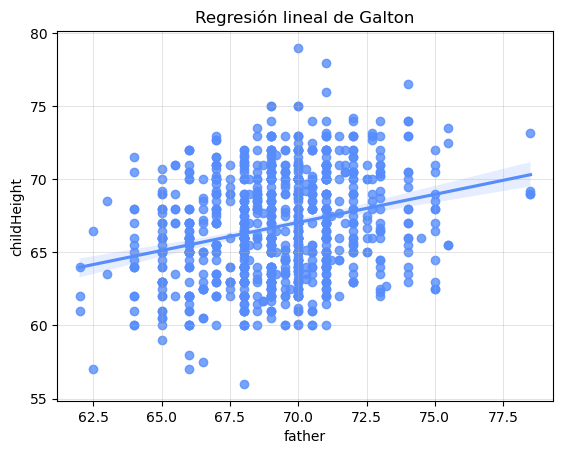

In [2]:
# Importamos seaborn y matplotlib para visualizar los resultados mediante graficas
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos un grafico de dispersion con la linea recta de regresion ajustada
sns.regplot(data=df, x='father', y='childHeight', fit_reg=True)

# Activamos la cuadricula de fondo para facilitar la lectura visual
plt.grid(True)

# Asignamos un titulo claro a la grafica
plt.title('Regresion lineal de Galton')

# Mostramos la grafica resultante en pantalla
plt.show()


In [8]:
# Ejemplo 2: Regresion lineal
# Caso de estudio: relacion entre anios de experiencia y salario en una empresa

import pandas as pd # Libreria para manejo y analisis de tablas de datos
import statsmodels.api as sm # Libreria para estimar modelos econometricos

# Leemos el archivo CSV local que contiene los registros de salarios
df = pd.read_csv(r'C:\Users\alfre\documentos_ssd\UNAM\Artículos\libro\data\salarios.csv')


In [9]:
# Mostramos el contenido de la tabla de datos en pantalla
df


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [14]:
# Definimos las variables para el modelo de regresion simple
# y: variable dependiente o respuesta (salario que queremos explicar)
# X: variable independiente o predictora (anios de experiencia acumulada)

X = df['YearsExperience'] # anios de experiencia laboral
y = df['Salary'] # salario anual en dolares


In [24]:
# Ajustamos un modelo de Minimos Cuadrados Ordinarios (OLS) sin termino constante
# Nota: al omitir la constante forzamos la recta a pasar por el origen (0,0)
modelo = sm.OLS(y, X).fit()

# Imprimimos la tabla de resultados estadisticos del modelo
print(modelo.summary())


                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.973
Model:                            OLS   Adj. R-squared (uncentered):              0.972
Method:                 Least Squares   F-statistic:                              1048.
Date:                Fri, 18 Sep 2026   Prob (F-statistic):                    2.56e-24
Time:                        18:25:32   Log-Likelihood:                         -327.28
No. Observations:                  30   AIC:                                      656.6
Df Residuals:                      29   BIC:                                      658.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [25]:
# Inspeccionamos los valores de la variable predictora X
X


0      1.1
1      1.3
2      1.5
3      2.0
4      2.2
5      2.9
6      3.0
7      3.2
8      3.2
9      3.7
10     3.9
11     4.0
12     4.0
13     4.1
14     4.5
15     4.9
16     5.1
17     5.3
18     5.9
19     6.0
20     6.8
21     7.1
22     7.9
23     8.2
24     8.7
25     9.0
26     9.5
27     9.6
28    10.3
29    10.5
Name: YearsExperience, dtype: float64

In [29]:
# Agregamos una columna constante de unos a la matriz X usando sm.add_constant
# Esto permite estimar el intercepto B0 (salario base cuando la experiencia es cero)
X_const = sm.add_constant(X)

# Visualizamos la nueva matriz que incluye la columna constante 'const'
X_const


,const,YearsExperience
0,1.0,1.1
1,1.0,1.3
2,1.0,1.5
3,1.0,2.0
4,1.0,2.2
5,1.0,2.9
6,1.0,3.0
7,1.0,3.2
8,1.0,3.2
9,1.0,3.7


In [28]:
# Ahora ajustamos el modelo de regresion lineal incluyendo el termino constante
modelo = sm.OLS(y, X_const).fit()

# Imprimimos el resumen estadistico del modelo con intercepto
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.14e-20
Time:                        18:33:19   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.579e+04   2273.053     

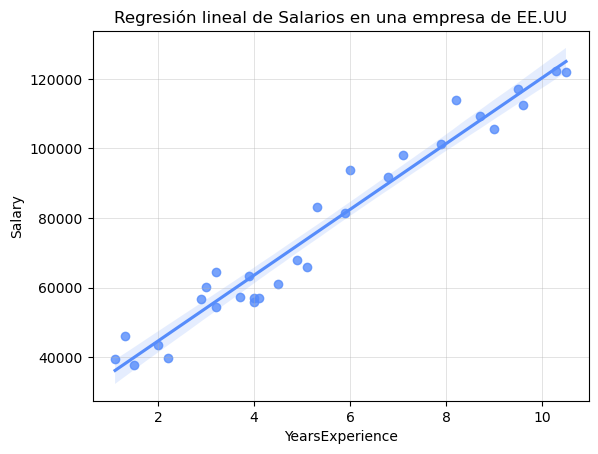

In [32]:
# Graficamos los datos observados junto con la recta de regresion estimada con constante
sns.regplot(data=df, x='YearsExperience', y='Salary', fit_reg=True)

# Habilitamos la cuadricula para mejorar la interpretacion
plt.grid(True)

# Colocamos un titulo explicativo al grafico
plt.title('Regresion lineal de Salarios en una empresa de EE.UU')

# Desplegamos la grafica en pantalla
plt.show()
